# Imports and basic settings

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import scipy.io
from scipy.stats import qmc
import matplotlib.pyplot as plt

torch.manual_seed(1234)
np.random.seed(1234)
torch.set_default_dtype(torch.float64)
os.makedirs("results", exist_ok=True)

# Load the reference solution

In [2]:
data = scipy.io.loadmat("data/burgers_shock.mat")
t_grid = data["t"].flatten()[:, None]
x_grid = data["x"].flatten()[:, None]
Exact = data["usol"]            # shape (256, 100): Exact[i, j] = u(x_i, t_j)

X, T = np.meshgrid(x_grid, t_grid)
X_star = np.hstack((T.flatten()[:, None], X.flatten()[:, None]))
u_star = Exact.T.flatten()[:, None]

lb = X_star.min(0)   # [t_min, x_min]
ub = X_star.max(0)   # [t_max, x_max]
print("t in", lb[0], "to", ub[0])
print("x in", lb[1], "to", ub[1])

t in 0.0 to 0.99
x in -1.0 to 1.0


## Pick the 100 training points (initial + boundary)

In [3]:
xx1 = np.hstack((X[0:1, :].T, T[0:1, :].T))   # t = 0 row
uu1 = Exact[:, 0:1]
xx2 = np.hstack((X[:, 0:1], T[:, 0:1]))       # x = -1 column
uu2 = Exact[0:1, :].T
xx3 = np.hstack((X[:, -1:], T[:, -1:]))       # x = 1 column
uu3 = Exact[-1:, :].T

X_u_train_all = np.vstack([xx1, xx2, xx3])[:, [1, 0]]   # reorder to (t, x)
u_train_all = np.vstack([uu1, uu2, uu3])

N_u = 100
idx = np.random.choice(X_u_train_all.shape[0], N_u, replace=False)
X_u_train = X_u_train_all[idx, :]
u_train = u_train_all[idx, :]
print(X_u_train.shape, u_train.shape)

(100, 2) (100, 1)


## Scatter 10,000 "physics-only" points

In [4]:
N_f = 10000
sampler = qmc.LatinHypercube(d=2, seed=1234)
sample = sampler.random(n=N_f)
X_f_train = lb + (ub - lb) * sample
X_f_train = np.vstack([X_f_train, X_u_train])
print(X_f_train.shape)

(10100, 2)


## Convert everything to PyTorch tensors

In [5]:
t_u = torch.tensor(X_u_train[:, 0:1], requires_grad=True)
x_u = torch.tensor(X_u_train[:, 1:2], requires_grad=True)
u_d = torch.tensor(u_train)

t_f = torch.tensor(X_f_train[:, 0:1], requires_grad=True)
x_f = torch.tensor(X_f_train[:, 1:2], requires_grad=True)

lb_t = torch.tensor(lb)
ub_t = torch.tensor(ub)

## The neural network itself

In [6]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList(
            [nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)]
        )
        for lin in self.linears:
            nn.init.xavier_normal_(lin.weight)
            nn.init.zeros_(lin.bias)

    def forward(self, t, x):
        X = torch.cat([t, x], dim=1)
        H = 2.0 * (X - lb_t) / (ub_t - lb_t) - 1.0   # rescale inputs to ~[-1,1]
        for lin in self.linears[:-1]:
            H = torch.tanh(lin(H))
        H = self.linears[-1](H)
        return H

layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
model = PINN(layers)
print(sum(p.numel() for p in model.parameters()), "trainable parameters")

3021 trainable parameters


## The physics residual

In [7]:
def net_u(t, x):
    return model(t, x)

def net_f(t, x):
    u = net_u(t, x)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    f = u_t + u * u_x - (0.01 / np.pi) * u_xx
    return f

## The loss (what we are minimizing)

In [8]:
def loss_fn():
    u_pred = net_u(t_u, x_u)
    f_pred = net_f(t_f, x_f) 
    mse_u = torch.mean((u_d - u_pred) ** 2)
    mse_f = torch.mean(f_pred ** 2)
    return mse_u + mse_f, mse_u, mse_f

## Train, part 1 (Adam optimizer warm-up)

In [9]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
for it in range(2000):
    optimizer_adam.zero_grad()
    loss, mse_u, mse_f = loss_fn()
    loss.backward()
    optimizer_adam.step()
    if it % 500 == 0:
        print(it, loss.item(), mse_u.item(), mse_f.item())

0 0.31635880527708093 0.2433360587071595 0.07302274656992143
500 0.04183303545452306 0.028935253412618028 0.012897782041905037
1000 0.012961797593094812 0.007268812125031172 0.005692985468063639
1500 0.009617135947998238 0.003117014881108992 0.006500121066889245


## Train, part 2 (L-BFGS fine-tuning)

In [10]:
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=1.0, max_iter=3000, max_eval=4000,
    history_size=50, tolerance_grad=1e-9, tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

iter_count = [0]
def closure():
    optimizer_lbfgs.zero_grad()
    loss, mse_u, mse_f = loss_fn()
    loss.backward()
    iter_count[0] += 1
    if iter_count[0] % 200 == 0:
        print(iter_count[0], loss.item())
    return loss

optimizer_lbfgs.step(closure)

200 0.0006340186559035026
400 0.0003100842012871618
600 0.00016578854488858618
800 0.00010062891849677762
1000 6.997476965340284e-05
1200 4.704079497970809e-05
1400 3.3777524667193316e-05
1600 2.5608039866216207e-05
1800 2.0717953140451966e-05
2000 1.6735284422345527e-05
2200 1.32295359795485e-05
2400 1.0256601218481819e-05
2600 8.769080281503078e-06
2800 7.63368597022835e-06
3000 6.582762049749236e-06
3200 5.762877042240035e-06


tensor(0.0047, grad_fn=<AddBackward0>)

## Check the result against the paper

In [14]:
with torch.no_grad():
    t_test = torch.tensor(X_star[:, 0:1])
    x_test = torch.tensor(X_star[:, 1:2])
    u_pred = net_u(t_test, x_test).numpy()

error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
print('Relative L2 error:', error_u)

Relative L2 error: 0.0049506223380298775


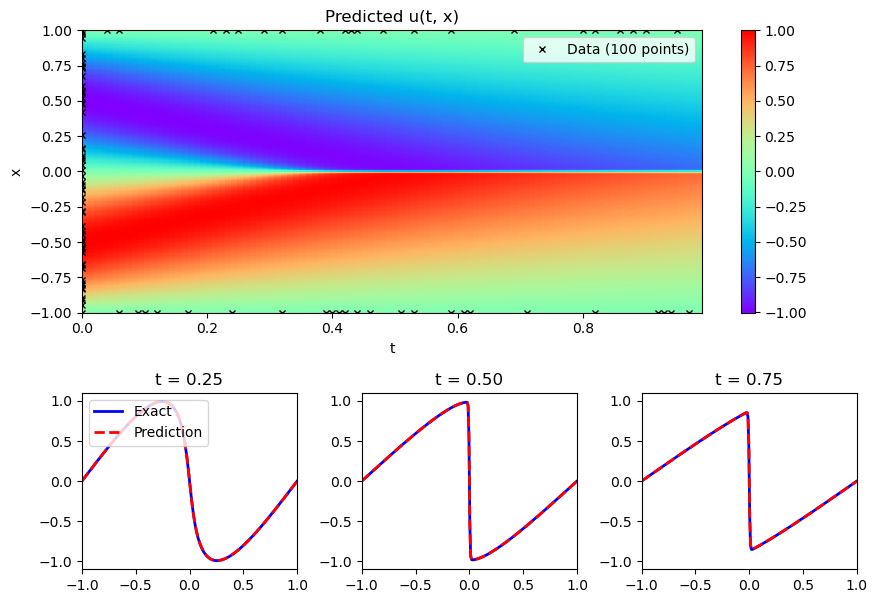

In [15]:
U_pred = u_pred.reshape(Exact.T.shape)

fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
h = ax1.imshow(U_pred.T, interpolation="nearest", cmap="rainbow",
               extent=[t_grid.min(), t_grid.max(), x_grid.min(), x_grid.max()],
               origin="lower", aspect="auto")
fig.colorbar(h, ax=ax1)
ax1.plot(X_u_train[:, 0], X_u_train[:, 1], "kx", markersize=4, label=f"Data ({N_u} points)")
ax1.set_xlabel("t"); ax1.set_ylabel("x"); ax1.set_title("Predicted u(t, x)")
ax1.legend(loc="upper right")

for i, tt in enumerate([0.25, 0.50, 0.75]):
    ax = fig.add_subplot(gs[1, i])
    idx_t = np.argmin(np.abs(t_grid.flatten() - tt))
    ax.plot(x_grid, Exact[:, idx_t], "b-", linewidth=2, label="Exact")
    ax.plot(x_grid, U_pred[idx_t, :], "r--", linewidth=2, label="Prediction")
    ax.set_title(f"t = {t_grid.flatten()[idx_t]:.2f}")
    ax.set_xlim(-1, 1); ax.set_ylim(-1.1, 1.1)
    if i == 0:
        ax.legend(loc="upper left")

plt.savefig("results/burgers_pinn_result.png", dpi=150, bbox_inches="tight")
plt.show()